In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

In [10]:
def format_by_sigma(x, sigma_x):
    exp = 0
    while not 1 < np.abs(sigma_x) < 10:
        if np.abs(sigma_x) < 10:
            sigma_x *= 10
            x *= 10
            exp -= 1
        else:
            sigma_x /= 10
            x /= 10
            exp += 1
    fmt = "{:.0f}"
    return x, sigma_x, fmt, exp

In [11]:
sigma_phi = 1       # делений
sigma_lambda = 0.5  # A

In [12]:
grad_data = pd.read_csv("grad.csv")
grad_data.head()

,line,lambda,grad
0,1,7032.41,2584
1,2,6929.47,2552
2,3,6717.04,2488
3,4,6678.28,2474
4,5,6598.95,2446


# Градуировка монохроматора


Аппроксимация градуировочной кривой:
$$ \lambda (\varphi) = \lambda_0 + \cfrac{C}{\varphi - \varphi_0} $$

Погршеность:
$$\sigma_\lambda = \sqrt{\left( \cfrac{\partial \lambda}{\partial \lambda_0}\right)^2 \sigma_{\lambda_0}^2 + \left(\cfrac{\partial \lambda}{\partial C}\right)^2 \sigma_{C}^2 + \left( \cfrac{\partial \lambda}{\partial \varphi_0}\right)^2\sigma_{\varphi_0}^2 + \left( \cfrac{\partial \lambda}{\partial \varphi}\right)^2 \sigma_{\varphi}^2} = \sqrt{\sigma_{\lambda_0}^2 + \left(\cfrac{\lambda - \lambda_0}{C}\right)^2 \sigma_{C}^2 + \left( \cfrac{\lambda - \lambda_0}{\varphi - \varphi_0}\right)^2 (\sigma_{\varphi_0}^2 + \sigma_{\varphi}^2) } $$

In [13]:
def lambda_func(x, lambda0, x0, c):
    return lambda0 + c / (x - x0)

In [14]:
def lambda_sigma_func(x, sigma_x, params, param_errs):
    lambda0, x0, c = params
    sigma_lambda0, sigma_x0, sigma_c = param_errs

    l = lambda_func(x, lambda0, x0, c)
    sigma_l = np.sqrt(
        sigma_lambda0**2  + 
        np.square((l - lambda0) / c) * sigma_c**2 + 
        np.square((l - lambda0) / (x - x0)) * (sigma_x**2 + sigma_x0**2)
    )

    return l, sigma_l

[ 2.37183478e+03  3.88790668e+03 -6.08484946e+06]
[6.55814550e+01 2.61472022e+01 2.04708102e+05]
Параметры
lambda_0 = (237 +- 7) * 10^1
varphi_0 = (389 +- 3) * 10^1
c        = (-61 +- 2) * 10^5


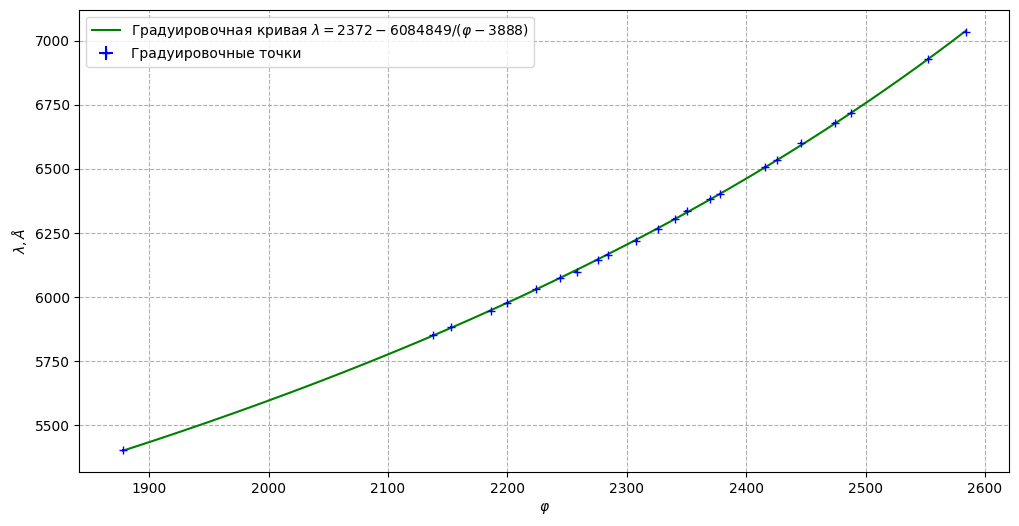

In [15]:
x = grad_data["grad"]
y = grad_data["lambda"]
dots_xy = list(zip(x, y))
dots_xy.sort(key=(lambda x: x[0]))
x_data, y_data = [], []
for x_, y_ in dots_xy:
    x_data.append(x_)
    y_data.append(y_)


popt_l, pcov_l = curve_fit(lambda_func, x_data, y_data, sigma=sigma_lambda, p0=(2000, 4000, -7000000), maxfev=1000)

popt_err_l = np.sqrt(np.diag(pcov_l))

print(popt_l)
print(popt_err_l)
popt_fmts = []
names = ["lambda_0", "varphi_0", "c       "]
print("Параметры")
for i in range(len(popt_l)):
    param, param_err, fmt, exp = format_by_sigma(popt_l[i], popt_err_l[i])
    print(f"{names[i]} = ({fmt.format(param)} +- {fmt.format(param_err)}) * 10^{exp}")


x_model = np.linspace(min(x_data), max(x_data), 10000)
y_model = lambda_func(x_model, *popt_l)

plt.figure(figsize=(12, 6))

plt.plot(x_model, y_model, "g", label=rf"Градуировочная кривая $\lambda = {popt_l[0]:.0f} {popt_l[2]:.0f} / (\varphi - {popt_l[1]:.0f})$")
plt.errorbar(grad_data["grad"], grad_data["lambda"], xerr=sigma_phi, yerr=sigma_lambda, fmt="+b", label="Градуировочные точки")


plt.grid(True, linestyle='--')

plt.ylabel(r"$\lambda, \AA$")
plt.xlabel(r"$\varphi$")

plt.legend()
plt.savefig('pics/grad_graph')
plt.show()

# Измерение фототока от напряжения




При настрйоке тока

Длина волны: $\varphi = 2448, \ V = 7.144 \ \text{В}, \ I = 0.500 \ \text{В}$

Меряем при $\varphi = 2138, \ \lambda = 5852 \ \AA$

Напряжение пропорциональное фототоку (I [В]) от потенциала на фотоэлементе (V [В])


Погрешности $\sigma_V = 0.003$ В, $\sigma_I = 0.002$ В

In [16]:
I_temnovoy = 0.006 # V 

In [17]:
photocurrent_data_2138 = pd.read_csv("photocurrent_voltage_2138.csv")

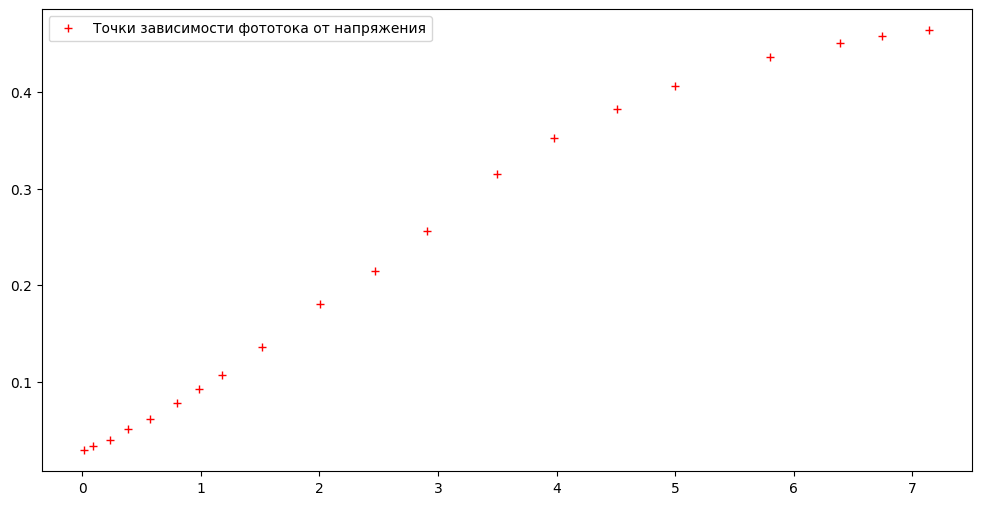

In [18]:

plt.figure(figsize=(12, 6))

plt.plot(photocurrent_data_2138["V"], photocurrent_data_2138["I"], "+r", label=r"Точки зависимости фототока от напряжения")

plt.legend()
plt.show()

Меряем фотока при $\varphi = 2570$

In [19]:
photocurrent_data_2570 = pd.read_csv("photocurrent_voltage_2570.csv")

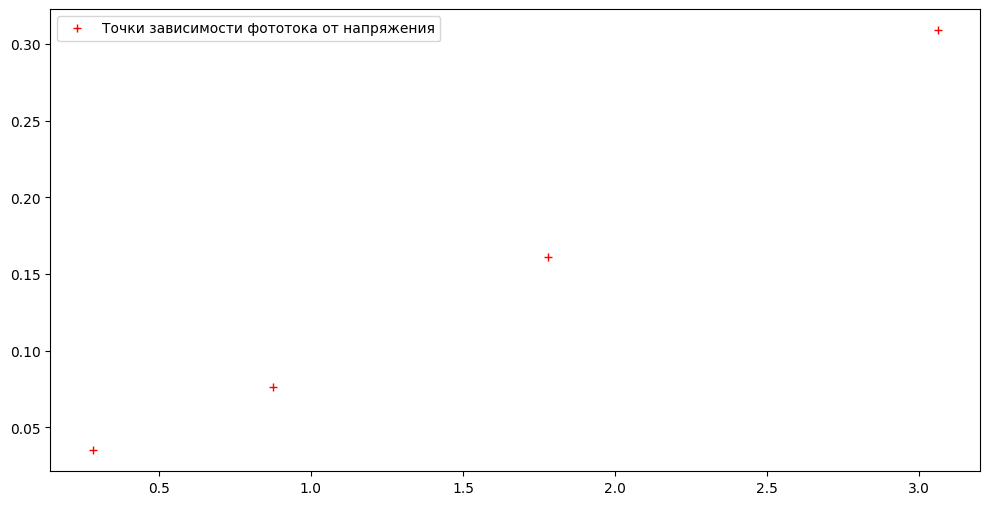

In [20]:

plt.figure(figsize=(12, 6))

plt.plot(photocurrent_data_2570["V"], photocurrent_data_2570["I"], "+r", label=r"Точки зависимости фототока от напряжения")

plt.legend()
plt.show()

Меряем фотока при $\varphi = 2470$

In [21]:
photocurrent_data_2470 = pd.read_csv("photocurrent_voltage_2470.csv")

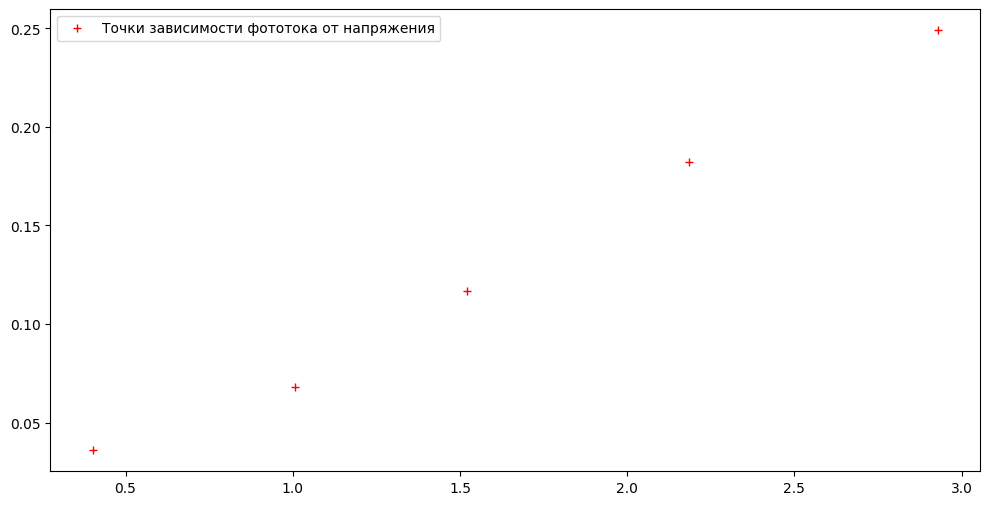

In [22]:

plt.figure(figsize=(12, 6))

plt.plot(photocurrent_data_2470["V"], photocurrent_data_2470["I"], "+r", label=r"Точки зависимости фототока от напряжения")

plt.legend()
plt.show()

Меряем фотока при $\varphi = 2370$

In [23]:
photocurrent_data_2370 = pd.read_csv("photocurrent_voltage_2370.csv")

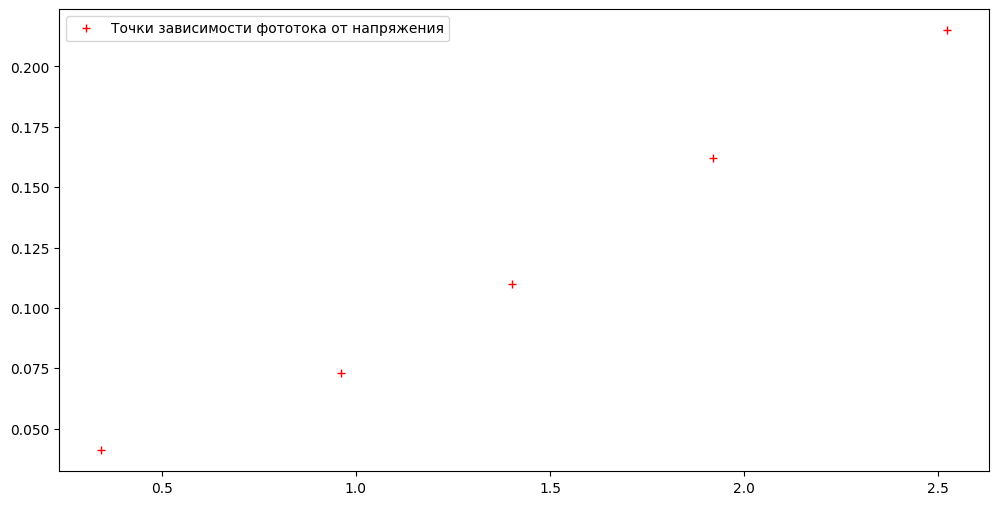

In [24]:

plt.figure(figsize=(12, 6))

plt.plot(photocurrent_data_2370["V"], photocurrent_data_2370["I"], "+r", label=r"Точки зависимости фототока от напряжения")

plt.legend()
plt.show()

Меряем фотока при $\varphi = 2270$

In [25]:
photocurrent_data_2270 = pd.read_csv("photocurrent_voltage_2270.csv")

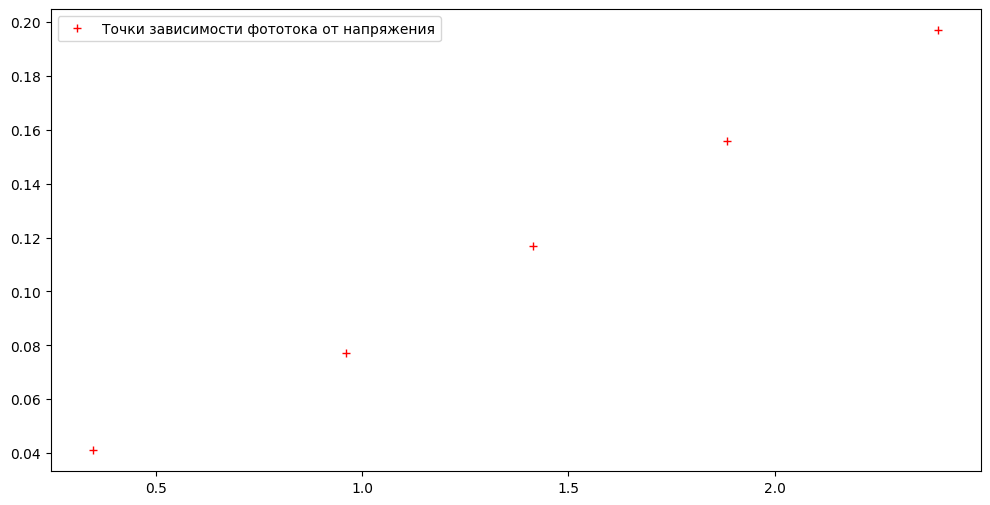

In [26]:

plt.figure(figsize=(12, 6))

plt.plot(photocurrent_data_2270["V"], photocurrent_data_2270["I"], "+r", label=r"Точки зависимости фототока от напряжения")

plt.legend()
plt.show()

## Обработка

In [27]:
phis = ["2138", "2270", "2370", "2470", "2570"]

photocurrent_data = {
    phi: pd.read_csv(f"photocurrent_voltage_{phi}.csv") for phi in phis
}

In [28]:
lambdas = {}

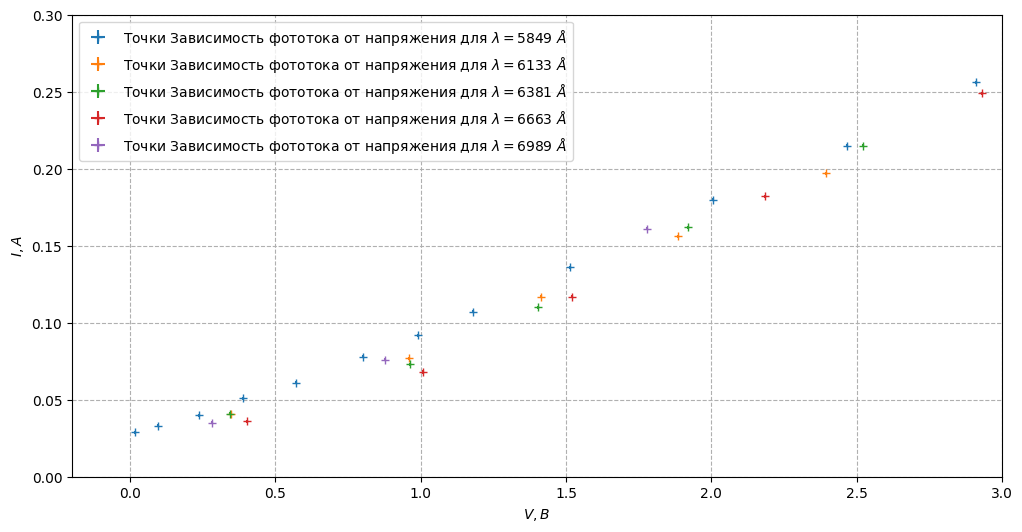

In [29]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle='--')

for phi in phis:
    x = photocurrent_data[phi]["V"]
    y = photocurrent_data[phi]["I"]

    p = np.float64(phi)

    l, sigma_l = lambda_sigma_func(p, 1, popt_l, popt_err_l)

    lambdas[phi] = {
        "val": l,
        "err": sigma_l
    }


    plt.errorbar(x=x, y=y, xerr=0.001, yerr=0.001, fmt="+", label=fr"Точки Зависимость фототока от напряжения для $\lambda = {l:.0f}~\AA$")



plt.xlabel(r"$V, В$")
plt.ylabel(r"$I, А$")

plt.ylim(0, 0.3)
plt.xlim(-0.2, 3)

plt.legend()
plt.savefig("pics/photocurs")
plt.show()


In [30]:
def line(x, k, b):
    return k*x + b

In [31]:
line_params = {}

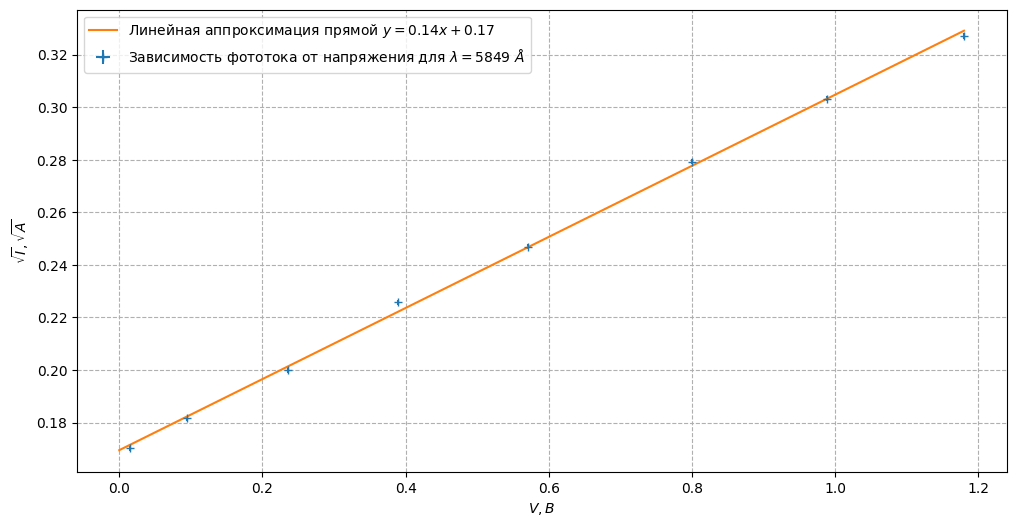

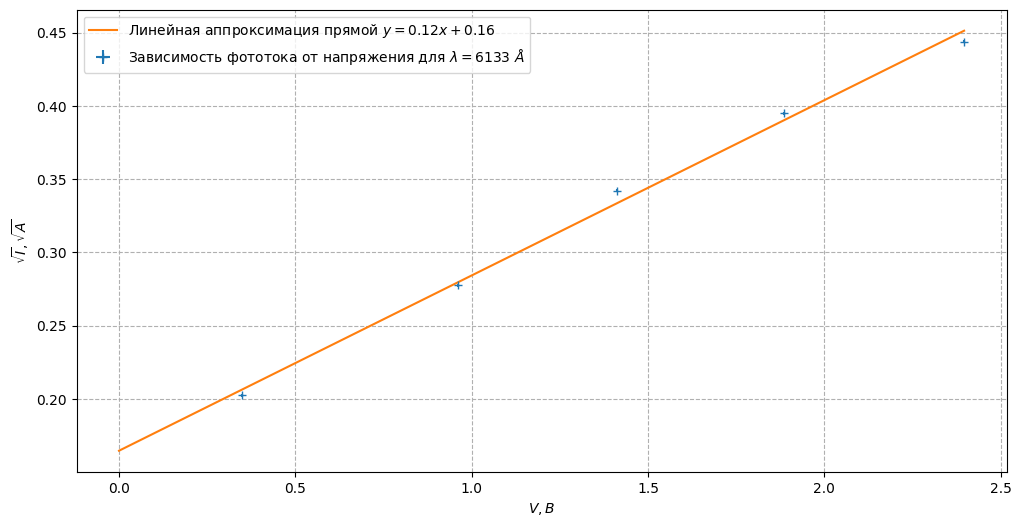

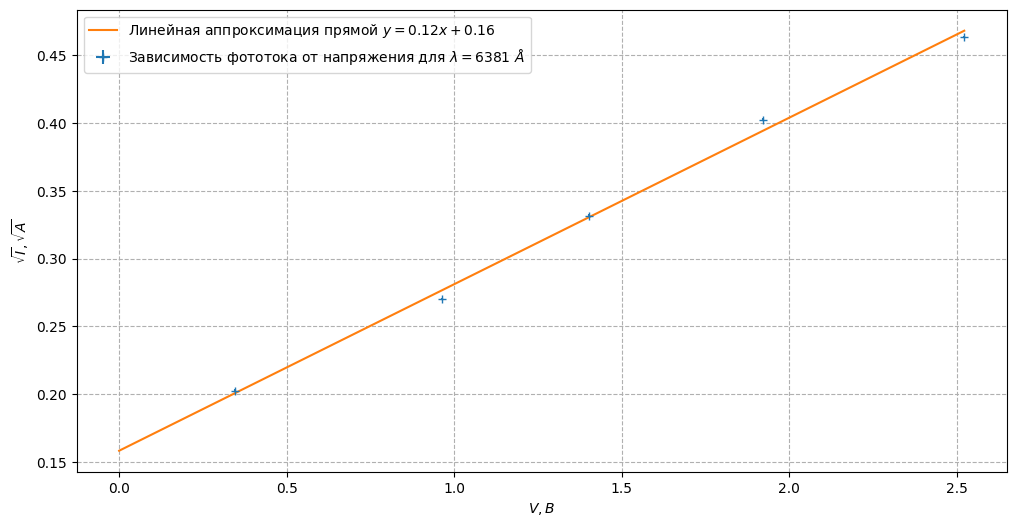

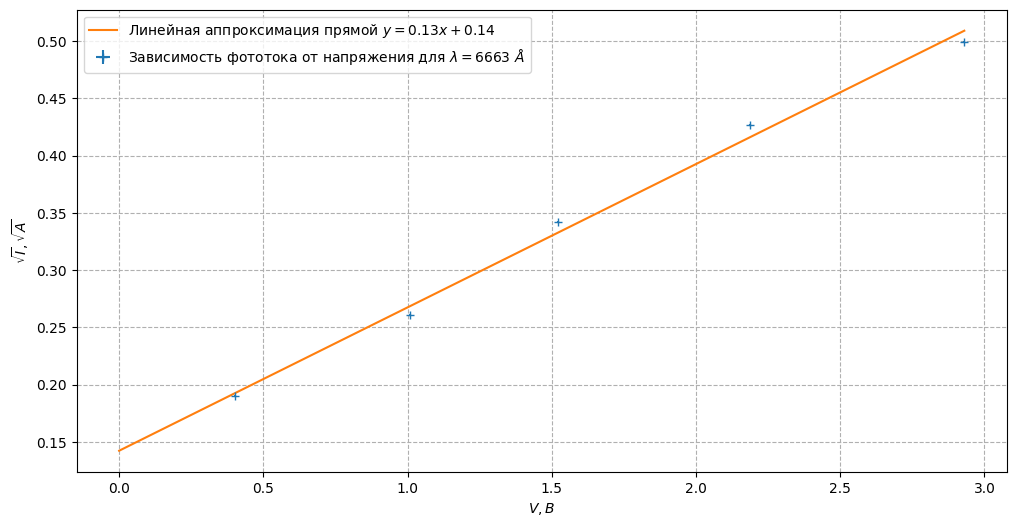

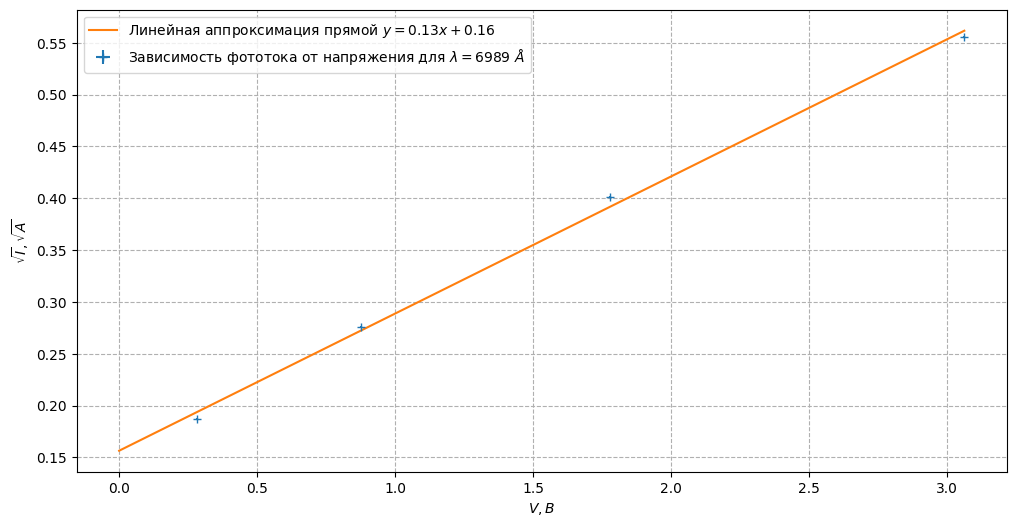

In [32]:
for phi in phis:
    plt.figure(figsize=(12, 6))
    plt.grid(True, linestyle='--')
    x = photocurrent_data[phi]["V"]
    y = np.sqrt(photocurrent_data[phi]["I"])

    if phi == "2138":
        x = x[12:]
        y = y[12:]
        pass

    popt, pcov = curve_fit(line, x, y)
    popt_err = np.sqrt(np.diag(pcov))

    a, b = popt
    sigma_a, sigma_b = popt_err
    line_params[phi] = {
        "a": a,
        "sigma_a": sigma_a,
        "b": b,
        "sigma_b": sigma_b
    }

    x_model = np.linspace(0, max(x), 1000)
    y_model = line(x_model, *popt)

    l = lambdas[phi]["val"]

    plt.errorbar(x=x, y=y, xerr=0.001, yerr=0.001, fmt="+", label=fr"Зависимость фототока от напряжения для $\lambda = {l:.0f}~ \AA$")
    plt.plot(x_model, y_model, label=rf"Линейная аппроксимация прямой $y = {a:.2f}x + {b:.2f}$")


    plt.xlabel(r"$V, В$")
    plt.ylabel(r"$\sqrt{I}, \sqrt{А}$")

    plt.legend()
    plt.savefig(f"pics/photocurs_sqrtI_{phi}")
    plt.show()


$$ \sqrt{I} = aV + b $$

Запирающий потенциал когда $I = 0 \implies$

$$ 0 = a V_0 + b \implies V_0 = \left| \cfrac{b}{a} \right| $$

In [33]:
def model_monte_karlo(a, sigma_a, b, sigma_b, dots=2000, sim=10000):
    a_grid = np.linspace(a - sigma_a, a + sigma_a, dots)
    b_grid = np.linspace(b - sigma_b, b + sigma_b, dots)

    lines_grid = [(ai, bi) for ai in a_grid for bi in b_grid]

    V_0s = []

    for _ in range(sim):

        aj, bj = lines_grid[int(len(lines_grid)*np.random.random())]

        V_0s.append(bj / aj)
    
    return V_0s

In [34]:
import seaborn as sns

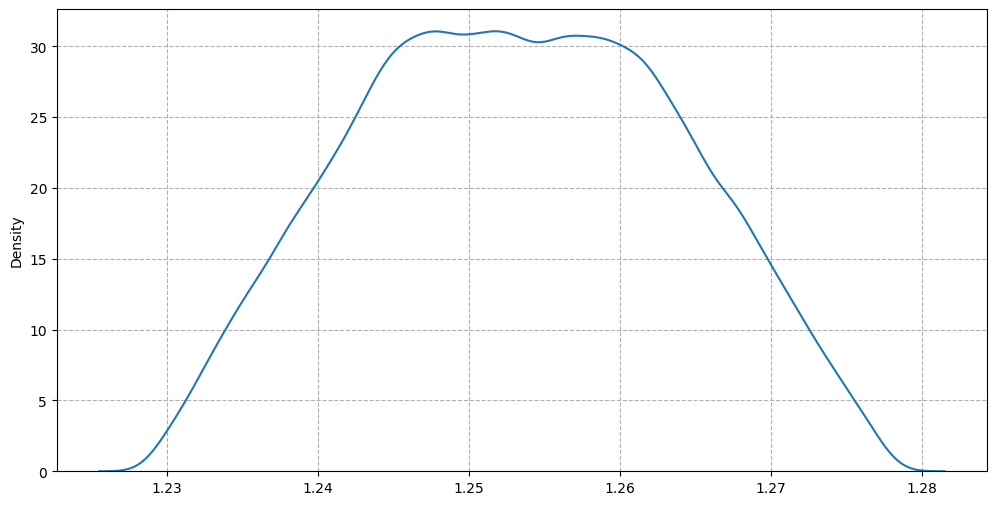

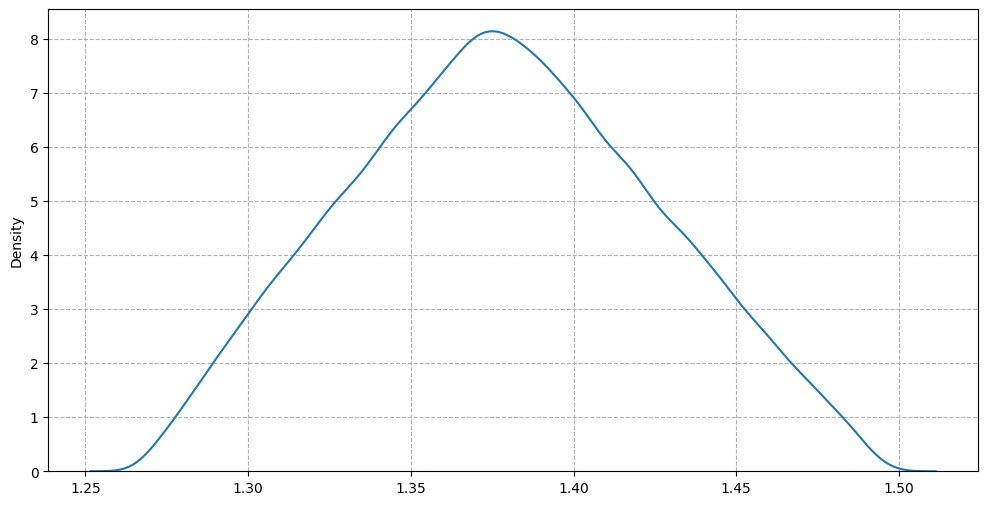

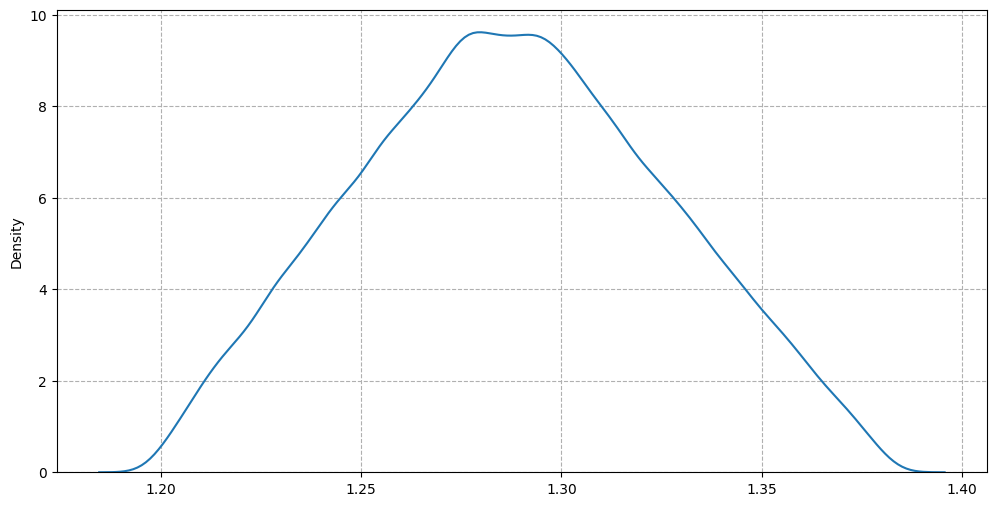

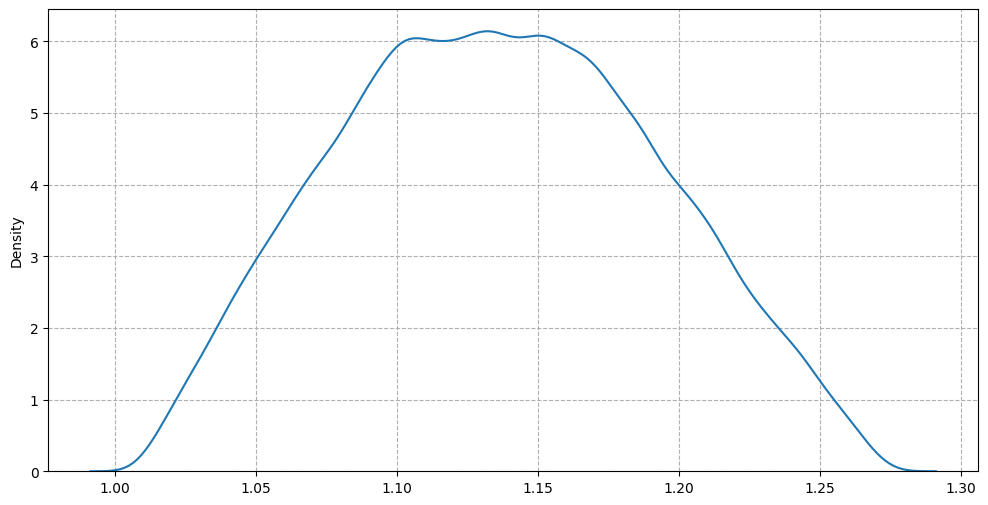

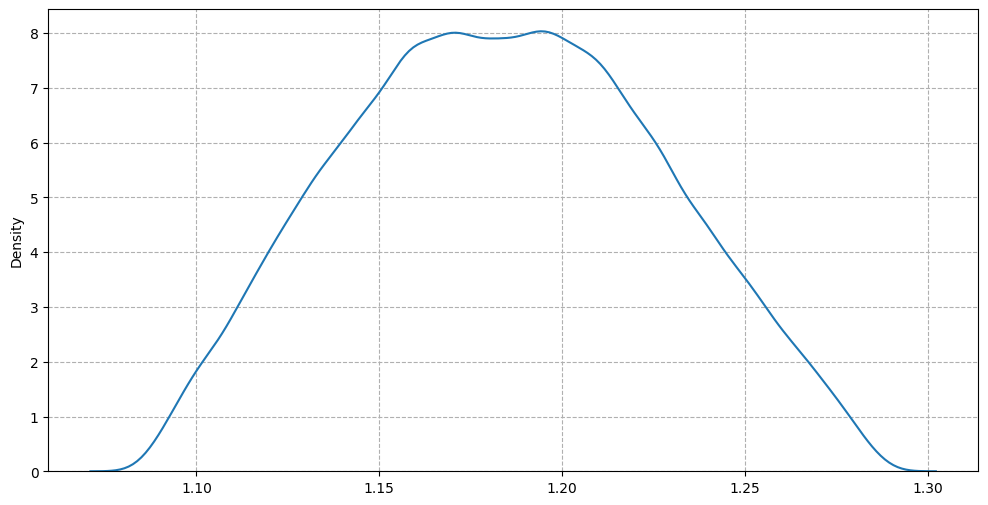

In [35]:
for phi in phis:
    plt.figure(figsize=(12, 6))
    plt.grid(True, linestyle='--')

    V_0s = model_monte_karlo(**line_params[phi], dots=1000, sim=100000)

    sns.kdeplot(V_0s)

In [36]:
phi_data = {
    "phi": [],
    "sigma_phi": [],
    "lambda": [],
    "sigma_lambda": [],
    "omega": [],
    "sigma_omega": [],
    "a": [],
    "sigma_a": [],
    "b": [],
    "sigma_b": []
}

for phi in phis:
    phi_data["phi"].append(np.float64(phi))
    phi_data["sigma_phi"].append(np.float64('1'))

    l = lambdas[phi]["val"]
    sigma_l = lambdas[phi]["err"]

    phi_data["lambda"].append(l)
    phi_data["sigma_lambda"].append(sigma_l)

    omega = 2* np.pi * 3e8 * 1e10 / l
    sigma_omega = omega * sigma_l / l

    phi_data["omega"].append(omega)
    phi_data["sigma_omega"].append(sigma_omega)

    a = line_params[phi]["a"]
    sigma_a = line_params[phi]["sigma_a"]
    b = line_params[phi]["b"]
    sigma_b = line_params[phi]["sigma_b"]

    phi_data["a"].append(a)
    phi_data["sigma_a"].append(sigma_a)
    phi_data["b"].append(b)
    phi_data["sigma_b"].append(sigma_b)

phi_data = pd.DataFrame(phi_data)

phi_data["V_0"] = phi_data["b"] / phi_data["a"]
phi_data["sigma_V_0"] = phi_data["V_0"] * np.sqrt(
    np.square(phi_data["sigma_a"] / phi_data["a"]) + 
    np.square(phi_data["sigma_b"] / phi_data["b"])
)

phi_data

,phi,sigma_phi,lambda,sigma_lambda,omega,sigma_omega,a,sigma_a,b,sigma_b,V_0,sigma_V_0
0,2138.0,1.0,5849.077040,143.837681,3.222655e+15,7.924997e+13,0.135267,0.001753,0.169509,0.001168,1.253140,0.018395
1,2270.0,1.0,6132.774476,154.950398,3.073577e+15,7.765686e+13,0.119596,0.004692,0.164686,0.007368,1.377017,0.081938
2,2370.0,1.0,6380.545946,165.118322,2.954223e+15,7.645057e+13,0.122934,0.003980,0.158232,0.006433,1.287130,0.066895
3,2470.0,1.0,6663.266327,177.246877,2.828876e+15,7.524980e+13,0.125198,0.005611,0.142165,0.010301,1.135518,0.096741
4,2570.0,1.0,6988.891169,191.914080,2.697074e+15,7.406131e+13,0.132294,0.004512,0.156532,0.008256,1.183216,0.074317


[ 9.88777252e-16 -1.65253846e+00]
[1.31655395e-16 3.88898923e-01]
h = 1.5820436027260463 +- 0.2106486325599028


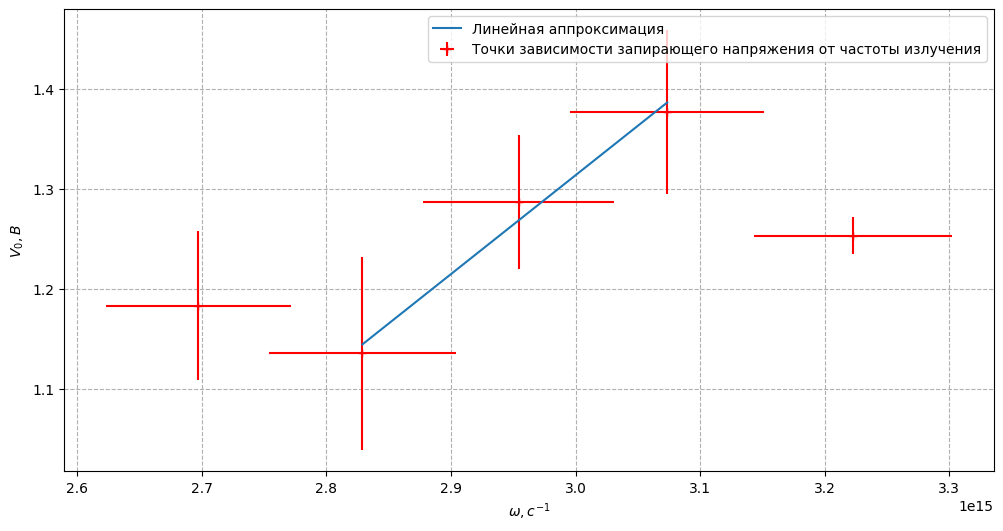

In [41]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle='--')

x = phi_data["omega"][1:-1]
y = phi_data["V_0"][1:-1]

popt, pcov = curve_fit(line, x, y)
perr = np.sqrt(np.diag(pcov))

print(popt)
print(perr)
e = np.float128('1.6e-19')

h = popt[0] * e * 1e34
sigma_h = perr[0] * e * 1e34
print(f"h = {h} +- {sigma_h}")

x_model = np.linspace(min(x), max(x), 1000)
y_model = line(x_model, *popt)

plt.errorbar(x=phi_data["omega"], xerr=phi_data["sigma_omega"], y=phi_data["V_0"], yerr=phi_data["sigma_V_0"], fmt="+r", label="Точки зависимости запирающего напряжения от частоты излучения")
plt.plot(x_model, y_model, label="Линейная аппроксимация")

plt.xlabel(r"$\omega, с^{-1}$")
plt.ylabel(r"$V_0, В$")

plt.legend()
plt.savefig('pics/V_0-omega')
plt.show()

In [38]:
def fmt_float(x, ndigits):
    """Format float with fixed ndigits and decimal comma."""
    if pd.isna(x):
        return ""
    return f"{x:.{ndigits}f}".replace(".", ",")


In [39]:
precisions = {
    "phi": 0, "sigma_phi": 0,
    "lambda": 2, "sigma_lambda": 2,
    "omega": 2, "sigma_omega": 2,
    "a": 3, "sigma_a": 3,
    "b": 3, "sigma_b": 3,
    "V_0": 3, "sigma_V_0": 3,
}

formatters = {
    col: (lambda nd: (lambda x, nd=nd: fmt_float(x, nd)))(nd)
    for col, nd in precisions.items()
}


In [ ]:
latex_table = phi_data.to_latex(
    index=False,
    formatters=formatters,
    column_format="|" + "c|" * len(phi_data.columns),  # вертикальные линии
    escape=False,  # если в заголовках будут спецсимволы LaTeX
)
print(latex_table)

\begin{tabular}{|c|c|c|c|c|c|c|c|c|c|c|c|}
\toprule
phi & sigma_phi & lambda & sigma_lambda & omega & sigma_omega & a & sigma_a & b & sigma_b & V_0 & sigma_V_0 \\
\midrule
2138 & 1 & 5849,08 & 143,84 & 3222654752900028,00 & 79249971090241,11 & 0,135 & 0,002 & 0,170 & 0,001 & 1,253 & 0,018 \\
2270 & 1 & 6132,77 & 154,95 & 3073577219284360,50 & 77656860917923,19 & 0,120 & 0,005 & 0,165 & 0,007 & 1,377 & 0,082 \\
2370 & 1 & 6380,55 & 165,12 & 2954223052351753,50 & 76450566441081,28 & 0,123 & 0,004 & 0,158 & 0,006 & 1,287 & 0,067 \\
2470 & 1 & 6663,27 & 177,25 & 2828876259143554,00 & 75249803424427,02 & 0,125 & 0,006 & 0,142 & 0,010 & 1,136 & 0,097 \\
2570 & 1 & 6988,89 & 191,91 & 2697073894076272,50 & 74061312779493,77 & 0,132 & 0,005 & 0,157 & 0,008 & 1,183 & 0,074 \\
\bottomrule
\end{tabular}

